Google Colabで実行:

https://colab.research.google.com/github/genkuroki/public/blob/main/0057/one%20sample%20t-test.ipynb

In [1]:
haskey(ENV, "COLAB_GPU") && (import Pkg; Pkg.add("Distributions"))

false

In [2]:
_nthreads() = Threads.nthreads(:interactive) + Threads.nthreads(:default)
using Random
using Distributions
distname(dist) = replace(string(dist), r"{[^\}]*}"=>"")
distname(dist::InverseGamma) = "InverseGamma(α=$(shape(dist)), θ=$(scale(dist)))"
using Plots
default(fmt=:png)

_ecdf(A, x) = count(≤(x), A) / length(A)

function pvalues(x, mu=0.0)
    n, xbar, s2 = length(x), mean(x), var(x)
    t = (xbar - mu) / sqrt(s2 / n)
    pval_tdist = 2ccdf(TDist(n-1), abs(t))
    pval_normal = 2ccdf(Normal(), abs(t))
    pval_tdist, pval_normal
end

function sim(dist; 
        mu=mean(dist), ns=[10, 30, 50, 100, 200], niters=10^6)
    Xtmp = [zeros(eltype(dist), n) for _ in 1:_nthreads(), n in ns]
    pval_tdist = zeros(niters, length(ns))
    pval_normal = zeros(niters, length(ns))
    for j in 1:length(ns)
        Threads.@threads :static for i in 1:niters
            tid = Threads.threadid()
            X = rand!(dist, Xtmp[tid, j])
            pval_tdist[i, j], pval_normal[i, j] = pvalues(X, mu)
        end
    end
    (; pval_tdist, pval_normal, dist, mu, ns, niters)
end

function plot_alphaerrors(dist; 
        mu=mean(dist), ns=[10, 30, 50, 100, 200], alpha=0.05, niters=4*10^6, 
        xlim=(-2, 205), ylim=(0.045, 0.1), xtick=0:25:200, ytick=0:0.005:1, kwargs...)
    (; pval_tdist, pval_normal) = sim(dist; mu, ns, niters)
    alphaerror_tdist = [_ecdf(@view(pval_tdist[:, j]), alpha) for j in 1:length(ns)]
    alphaerror_normal = [_ecdf(@view(pval_normal[:, j]), alpha) for j in 1:length(ns)]
    
    plot(ns, alphaerror_tdist; marker=:o, label="by t-distribution")
    plot!(ns, alphaerror_normal; marker=:square, label="by std normal dist.")
    hline!([alpha]; c=:red, alpha=0.5, label="nominal alpha = $alpha")
    title!("$(distname(dist)),  mu=$(round(mu; sigdigits=3)),  niters=$niters")
    plot!(; xlim, ylim, xtick, ytick)
    plot!(; legendfontsize=12, titlefontsize=12)
    plot!(; kwargs...)
    
end

plot_alphaerrors (generic function with 1 method)

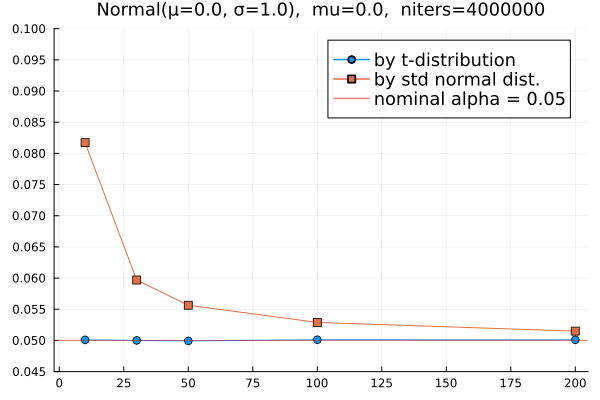

In [3]:
P1 = plot_alphaerrors(Normal())

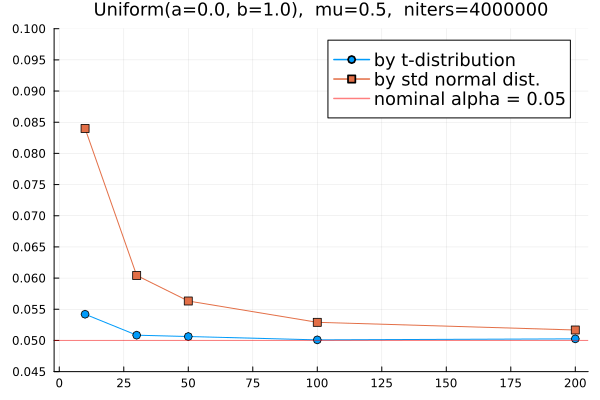

In [4]:
P2 = plot_alphaerrors(Uniform())

skewness(Poisson(0.8)) = 1.118033988749895


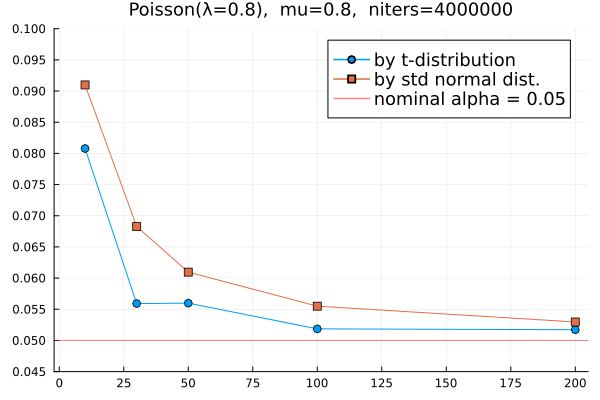

In [5]:
@show skewness(Poisson(0.8))
P3 = plot_alphaerrors(Poisson(0.8))

skewness(Gamma(3)) = 1.1547005383792517


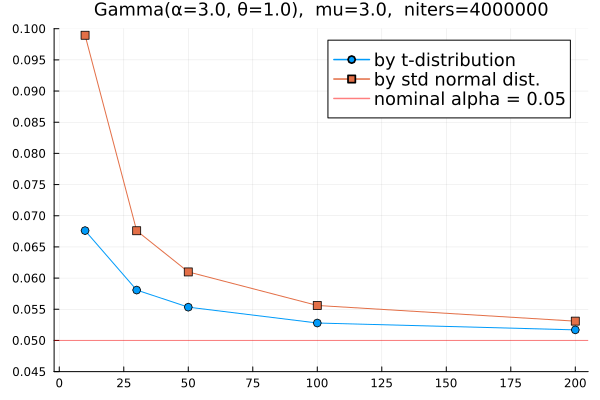

In [6]:
@show skewness(Gamma(3))
P4 = plot_alphaerrors(Gamma(3))

skewness(InverseGamma(4)) = 5.656854249492381


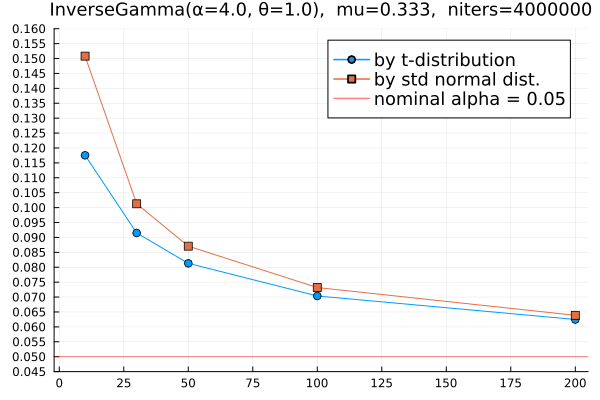

In [7]:
@show skewness(InverseGamma(4))
P5 = plot_alphaerrors(InverseGamma(4); ylim=(0.045, 0.16))

skewness(InverseGamma(4)) = 5.656854249492381


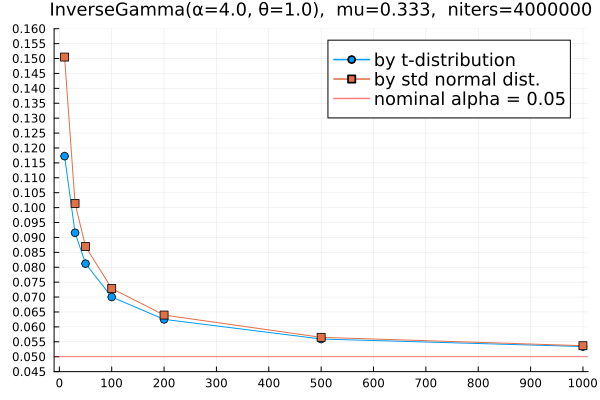

In [8]:
@show skewness(InverseGamma(4))
P6 = plot_alphaerrors(InverseGamma(4); 
    ns=[10, 30, 50, 100, 200, 500, 1000],
    xtick=0:100:1000, xlim=(-10, 1010), ylim=(0.045, 0.16))

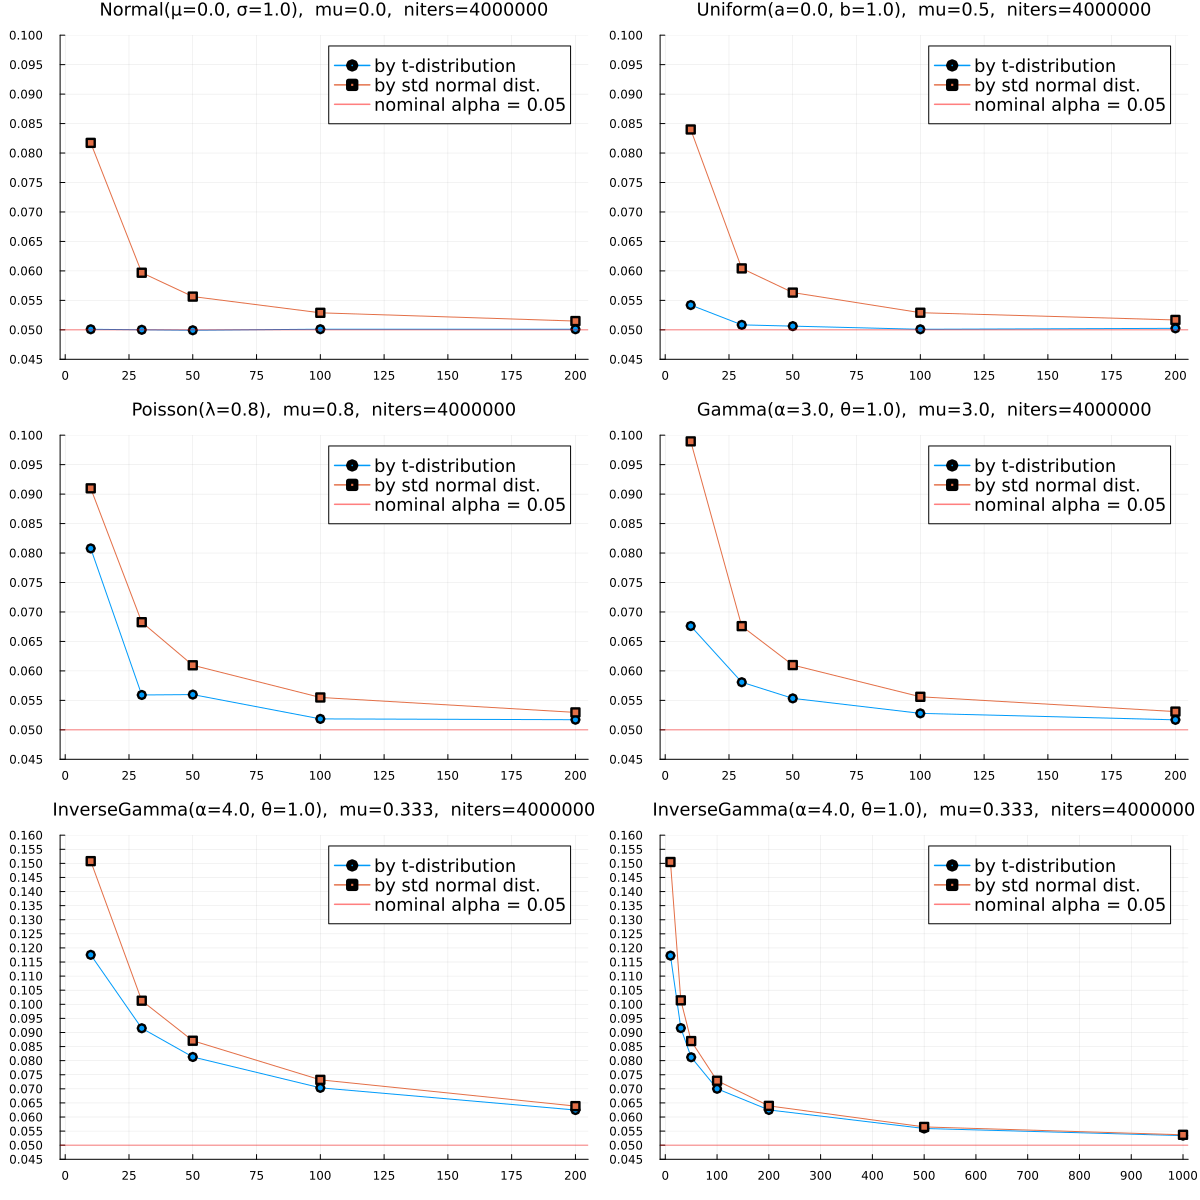

In [9]:
plot(P1, P2, P3, P4, P5, P6; size=(1200, 1200), layout=(3, 2))